<a href="https://colab.research.google.com/github/Asaf21S/constrained-flow-matching/blob/main/constrained_fm/notebooks/constrained_fm_2d_gmm_functa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [1]:
!pip install -q flow_matching POT

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.7/48.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 71.5 MB/s eta 0:00:00


In [2]:
import sys
import os
import math
import random
from pathlib import Path

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from matplotlib import cm
from torch.distributions import Categorical, Independent, MixtureSameFamily, MultivariateNormal, Normal
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

from flow_matching.path import AffineProbPath
from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.solver import ODESolver, Solver
from flow_matching.utils import ModelWrapper
from torch.func import vmap

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
!git clone https://github.com/Asaf21S/constrained-flow-matching.git

repo_path = '/content/constrained-flow-matching'
if repo_path not in sys.path:
    sys.path.append(repo_path)

Cloning into 'constrained-flow-matching'...
remote: Enumerating objects: 1007, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 1007 (delta 34), reused 53 (delta 21), pack-reused 938 (from 1)
Receiving objects: 100% (1007/1007), 173.37 MiB | 16.27 MiB/s, done.
Resolving deltas: 100% (457/457), done.


In [ ]:
# update the cloned repo after pushing changes in pycharm
%cd /content/constrained-flow-matching
!git pull origin main
%cd /content

/content/constrained-flow-matching
From https://github.com/Asaf21S/constrained-flow-matching
 * branch            main       -> FETCH_HEAD
Already up to date.
/content


In [6]:
import importlib

import constrained_fm.src.datasets.gmm_target
import constrained_fm.src.datasets.validation
import constrained_fm.src.datasets.constraints

import constrained_fm.src.geometry.polynomials
import constrained_fm.src.geometry.bounding_boxes

import constrained_fm.src.models.base_fm
import constrained_fm.src.models.unconstrained
import constrained_fm.src.models.constrained_bbox
import constrained_fm.src.models.constrained_poly
import constrained_fm.src.models.area_predictor
import constrained_fm.src.solvers.ode_wrapper

import constrained_fm.src.inference.evaluator
import constrained_fm.src.inference.compound_sampler
import constrained_fm.src.inference.importance_sampling

import constrained_fm.src.metrics.success_rates
import constrained_fm.src.metrics.logger

import constrained_fm.src.visualization.density
import constrained_fm.src.visualization.scatter
import constrained_fm.src.visualization.constraints

import constrained_fm.src.models.functa_siren
import constrained_fm.src.inference.latent_extractor

# 2. Reload them all (Order matters: base classes/math first, high-level last)
for _ in range(3):
    importlib.reload(constrained_fm.src.geometry.polynomials)
    importlib.reload(constrained_fm.src.geometry.bounding_boxes)

    importlib.reload(constrained_fm.src.datasets.gmm_target)
    importlib.reload(constrained_fm.src.datasets.validation)
    importlib.reload(constrained_fm.src.datasets.constraints)

    importlib.reload(constrained_fm.src.models.base_fm) # Reload base first!
    importlib.reload(constrained_fm.src.models.unconstrained)
    importlib.reload(constrained_fm.src.models.constrained_bbox)
    importlib.reload(constrained_fm.src.models.constrained_poly)
    importlib.reload(constrained_fm.src.models.area_predictor)
    importlib.reload(constrained_fm.src.solvers.ode_wrapper)

    importlib.reload(constrained_fm.src.metrics.success_rates)
    importlib.reload(constrained_fm.src.metrics.logger)

    importlib.reload(constrained_fm.src.visualization.density)
    importlib.reload(constrained_fm.src.visualization.scatter)
    importlib.reload(constrained_fm.src.visualization.constraints)

    importlib.reload(constrained_fm.src.inference.evaluator)
    importlib.reload(constrained_fm.src.inference.compound_sampler)
    importlib.reload(constrained_fm.src.inference.importance_sampling)

    importlib.reload(constrained_fm.src.models.functa_siren)
    importlib.reload(constrained_fm.src.inference.latent_extractor)

# Datasets & Constraints
from constrained_fm.src.datasets.gmm_target import get_points, compute_gmm_log_likelihood
from constrained_fm.src.datasets.validation import get_validation_set
from constrained_fm.src.datasets.constraints import sample_valid_polynomials, generate_mass_dataset_anchored

# Geometry & Math
from constrained_fm.src.geometry.polynomials import compute_poly_features, evaluate_poly, compute_poly_features_batched, evaluate_poly_batched
from constrained_fm.src.geometry.bounding_boxes import generate_disjoint_bboxes

# Models
from constrained_fm.src.models.unconstrained import UnconstrainedFM
from constrained_fm.src.models.constrained_bbox import BboxConstrainedFM
from constrained_fm.src.models.constrained_poly import PolynomialConstrainedFM
from constrained_fm.src.models.area_predictor import AreaPredictor
from constrained_fm.src.solvers.ode_wrapper import WrappedModel

# Inference & Evaluation Run
from constrained_fm.src.inference.evaluator import run_evaluation_inference, evaluate_single_configuration, evaluate_validation_set_metrics
from constrained_fm.src.inference.compound_sampler import generate_from_boxes, generate_compound_constrained_points
from constrained_fm.src.inference.importance_sampling import estimate_mass_importance_sampling

# Metrics & Logging
from constrained_fm.src.metrics.success_rates import (compute_success_rate_bbox,
                                                      compute_success_rate_polynomial,
                                                      evaluate_compound_metrics)
from constrained_fm.src.metrics.logger import (log_evaluation_metrics,
                                               load_logged_metrics,
                                               print_readme_metrics_table)

# Visualization
from constrained_fm.src.visualization.density import (visualize_true_gmm_likelihood,
                                                      visualize_likelihood,
                                                      visualize_tiled_reconstruction)
from constrained_fm.src.visualization.scatter import (visualize_single_step,
                                                      plot_loss_curve,
                                                      generate_and_visualize_samples)
from constrained_fm.src.visualization.constraints import (visualize_sampled_polynomials,
                                                          visualize_predicted_bbox_mass,
                                                          visualize_disjoint_bboxes,
                                                          visualize_compound_generation)

from constrained_fm.src.models.functa_siren import ModulatedSIREN, build_modulated_siren
from constrained_fm.src.inference.latent_extractor import extract_latent, extract_latents_batched

# Displaying Priors

In [ ]:
n_train_samples = 100000
x0 = torch.randn(n_train_samples, 2)
gmm_true_pool, x1_labels = get_points(100000, device=device)
x1, x1_labels = gmm_true_pool.cpu(), x1_labels.cpu()

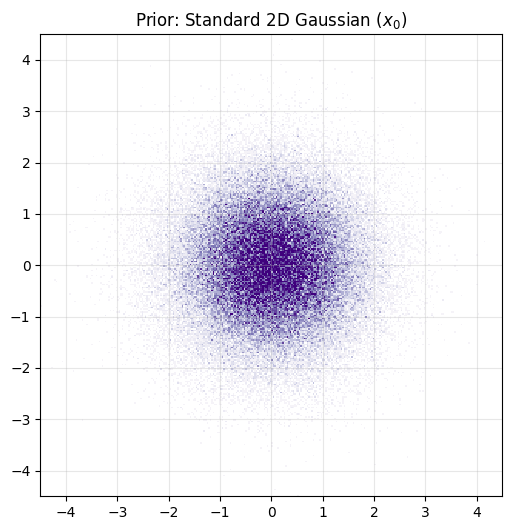

In [ ]:
visualize_single_step(x0, title="Prior: Standard 2D Gaussian ($x_0$)", cmap='Purples')
plt.show()

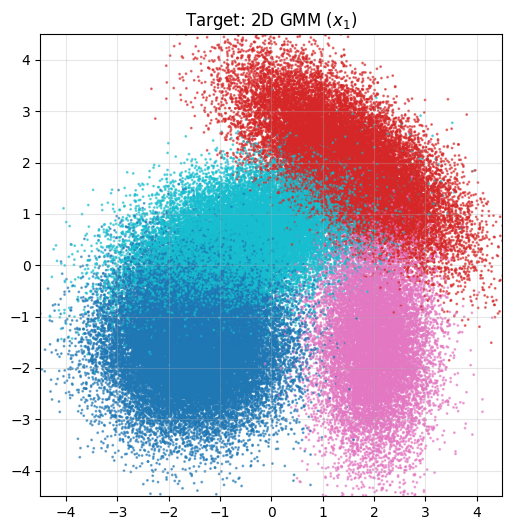

In [ ]:
visualize_single_step(x1, title="Target: 2D GMM ($x_1$)", cmap='Blues', labels=x1_labels)
plt.show()

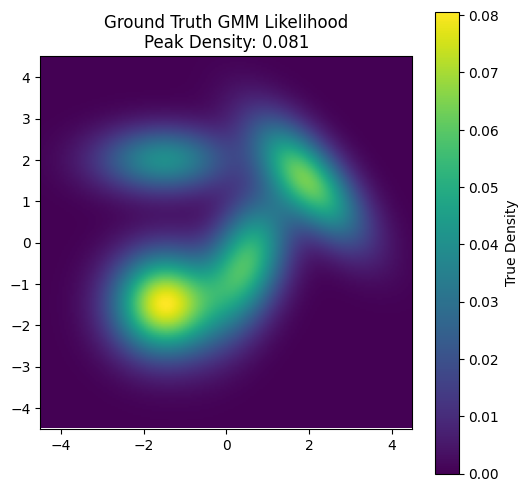

In [ ]:
visualize_true_gmm_likelihood(device=device)

# Functa

## Display polynomials dataset

In [ ]:
num_plots = 4
poly_degree = 3
plane_scale = 4.5
resolution = 200

In [ ]:
proxy_x, _ = get_points(batch_size=10000, device=device)
proxy_x = proxy_x.to(device)

proxy_x_batched = proxy_x.unsqueeze(0)
global_proxy_x_pow, global_proxy_y_pow = compute_poly_features_batched(proxy_x_batched, degree=poly_degree, scale=plane_scale)

In [9]:
C = sample_valid_polynomials(
    batch_size=num_plots,
    degree=poly_degree,
    scale=plane_scale,
    proxy_x_pow=global_proxy_x_pow.squeeze(0),
    proxy_y_pow=global_proxy_y_pow.squeeze(0),
    device=device
)

x_lin = torch.linspace(-plane_scale, plane_scale, resolution)
y_lin = torch.linspace(-plane_scale, plane_scale, resolution)
grid_y, grid_x = torch.meshgrid(y_lin, x_lin, indexing='ij')

grid_pts = torch.stack([grid_x, grid_y], dim=-1).view(-1, 2).unsqueeze(0).to(device)

grid_pts_batched = grid_pts.repeat(num_plots, 1, 1)

x_pow, y_pow = compute_poly_features_batched(grid_pts_batched, degree=poly_degree, scale=plane_scale)

P_vals = evaluate_poly_batched(x_pow, y_pow, C)

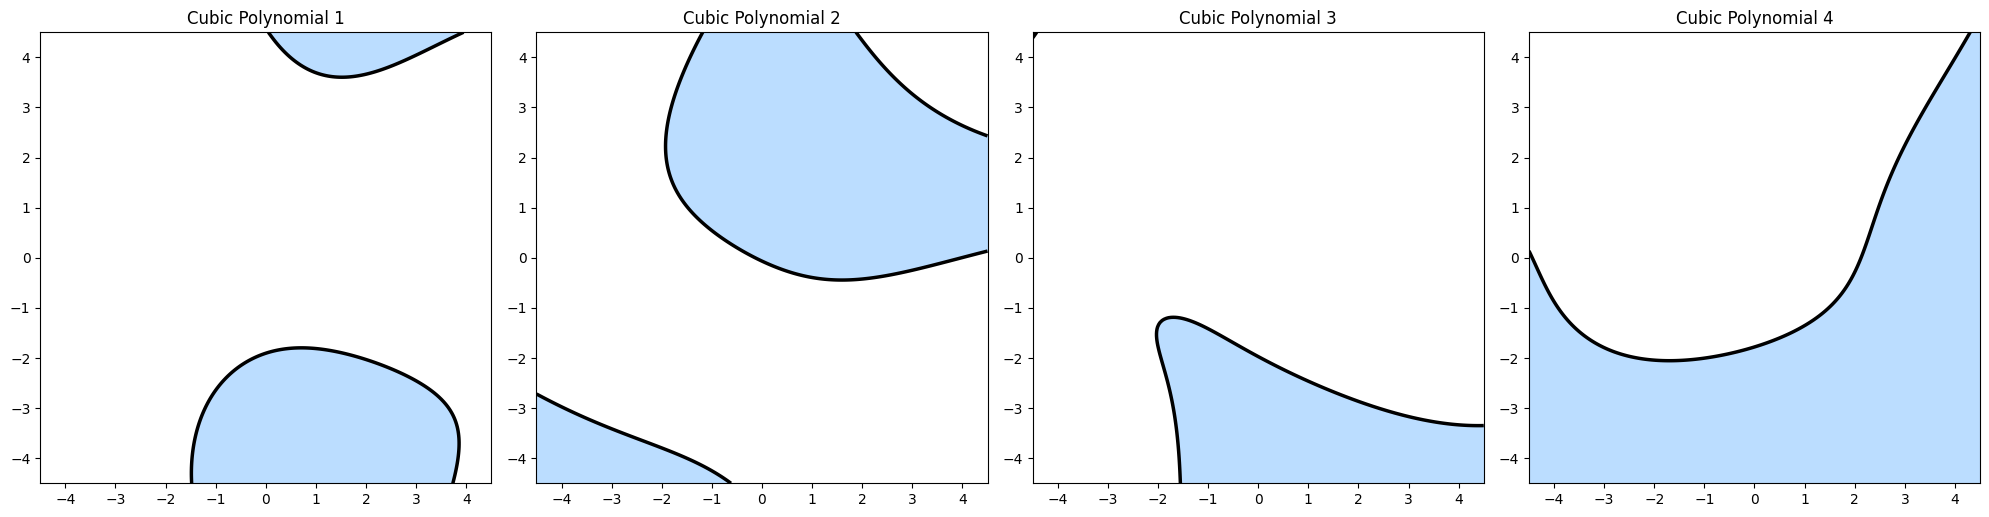

In [10]:
fig, axes = plt.subplots(1, num_plots, figsize=(5 * num_plots, 5))
if num_plots == 1: axes = [axes]

P_numpy = P_vals.view(num_plots, resolution, resolution).cpu().numpy()

for i in range(num_plots):
    ax = axes[i]

    # Shade the valid region P(x, y) <= 0
    ax.contourf(
        grid_x.numpy(), grid_y.numpy(), P_numpy[i],
        levels=[-float('inf'), 0], colors=['dodgerblue'], alpha=0.3
    )

    # Draw the exact boundary P(x, y) = 0
    ax.contour(
        grid_x.numpy(), grid_y.numpy(), P_numpy[i],
        levels=[0], colors='black', linewidths=2.5
    )

    ax.set_xlim(-plane_scale, plane_scale)
    ax.set_ylim(-plane_scale, plane_scale)
    ax.set_aspect('equal')
    ax.set_title(f"Cubic Polynomial {i+1}")

plt.tight_layout()
plt.show()

## Model

In [11]:
latent_dim=512
hidden_dim=512
n_layers=4
w0=30.0

siren = build_modulated_siren(latent_dim=latent_dim, hidden_dim=hidden_dim, n_layers=n_layers, w0=w0).to(device)

# Use cached model

In [12]:
# load model from cache
siren_path = Path("/content/constrained-flow-matching/constrained_fm/functa_dataset/siren_best.pt")
siren.load_state_dict(torch.load(siren_path, map_location=device, weights_only=True))
siren.eval()

ModulatedSIREN(
  (input_linear): Linear(in_features=2, out_features=512, bias=True)
  (hidden_linears): ModuleList(
    (0-3): 4 x Linear(in_features=512, out_features=512, bias=False)
  )
  (output_linear): Linear(in_features=512, out_features=1, bias=True)
  (film): FiLMModulation(
    (proj): Linear(in_features=512, out_features=4096, bias=True)
  )
)

In [13]:
train_loss_path = "/content/constrained-flow-matching/constrained_fm/functa_dataset/loss_history.npy"
val_loss_path = "/content/constrained-flow-matching/constrained_fm/functa_dataset/val_loss_history.npy"

loss_history = np.load(train_loss_path)
val_loss_history = np.load(val_loss_path)
val_epochs = val_loss_history[:, 0]
val_losses = val_loss_history[:, 1]

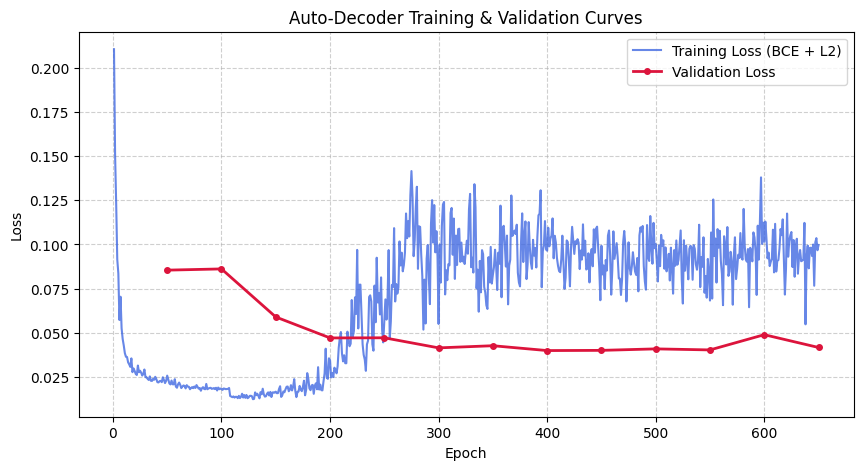

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(range(1, len(loss_history) + 1), loss_history, label="Training Loss (BCE + L2)", color="royalblue", alpha=0.8)

plt.plot(val_epochs, val_losses, label="Validation Loss", color="crimson", marker="o", markersize=4, linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Auto-Decoder Training & Validation Curves")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

# Run inference

In [15]:
def extract_functas_cavia(siren, X_batch, Y_batch, latent_dim=256, steps=3):
    """
    Exact replication of the meta-learned fast adaptation loop.
    No Adam, no L2 penalty, strictly 3 steps of SGD at the true meta-learned scale.
    """
    siren.eval()
    B = X_batch.shape[0]

    # Initialize zeroed Functa vectors
    z = torch.zeros(B, latent_dim, device=X_batch.device, requires_grad=True)

    # The true meta-learned learning rate from training (0.01 / 32)
    true_lr = 0.01 / 32.0

    # Use reduction='none' so we can cleanly separate the gradient per shape
    loss_fn = torch.nn.BCELoss(reduction='none')

    for step in range(steps):
        preds = siren(X_batch, z).squeeze(-1)

        # Mean over points, SUM over batch.
        # Summing ensures the gradient magnitude is independent of the inference batch size.
        bce_per_shape = loss_fn(preds, Y_batch).mean(dim=1)
        loss = bce_per_shape.sum()

        # Pure SGD step
        grad_z = torch.autograd.grad(loss, z)[0]
        z = z - true_lr * grad_z

    # Return the detached, perfectly adapted Functas
    return z.detach()

def test_final_pipeline(siren, num_shapes=4, scale=4.5, degree=3, resolution=250):
    device = next(siren.parameters()).device

    # 1. Generate new polynomials
    C = sample_valid_polynomials(
        batch_size=num_shapes, degree=degree, scale=scale,
        proxy_x_pow=global_proxy_x_pow.squeeze(0),
        proxy_y_pow=global_proxy_y_pow.squeeze(0), device=device
    )

    # 2. Sample 1500 fast-adaptation points
    X_raw = (torch.rand(num_shapes, 10000, 2, device=device) * (scale * 2)) - scale
    x_pow, y_pow = compute_poly_features_batched(X_raw, degree=degree, scale=scale)
    P_vals = torch.einsum('bmi, bij, bmj -> bm', x_pow, C, y_pow)
    Y = (P_vals <= 0).to(torch.float32)

    # 3. Extract latents using the strict CAVIA rule
    print("Extracting Functas (3 strict SGD steps)...")
    z_opt = extract_functas_cavia(siren, X_raw, Y, steps=15)

    # Calculate extraction loss
    with torch.no_grad():
        preds = siren(X_raw, z_opt).squeeze(-1)
        final_loss = torch.nn.BCELoss()(preds, Y).item()
    print(f"Extraction Loss: {final_loss:.6f} (Should be ~0.07 - 0.09)")

    # 4. Render the high-res visualization
    x_lin = torch.linspace(-scale, scale, resolution)
    y_lin = torch.linspace(-scale, scale, resolution)
    grid_y, grid_x = torch.meshgrid(y_lin, x_lin, indexing='ij')
    grid_pts_raw = torch.stack([grid_x, grid_y], dim=-1).view(-1, 2).unsqueeze(0).to(device).repeat(num_shapes, 1, 1)

    x_pow_grid, y_pow_grid = compute_poly_features_batched(grid_pts_raw, degree=degree, scale=scale)
    P_grid = torch.einsum('bmi, bij, bmj -> bm', x_pow_grid, C, y_pow_grid).view(num_shapes, resolution, resolution).cpu().numpy()

    with torch.no_grad():
        preds_grid = siren(grid_pts_raw, z_opt).squeeze(-1).view(num_shapes, resolution, resolution).cpu().numpy()

    # 5. Plot
    fig, axes = plt.subplots(1, num_shapes, figsize=(5 * num_shapes, 5))
    if num_shapes == 1: axes = [axes]

    for i in range(num_shapes):
        axes[i].contourf(grid_x.numpy(), grid_y.numpy(), preds_grid[i], levels=[0.5, 1.0], colors=['dodgerblue'], alpha=0.4)
        axes[i].contour(grid_x.numpy(), grid_y.numpy(), P_grid[i], levels=[0], colors=['black'], linewidths=2.0, linestyles='dashed')
        axes[i].set_aspect('equal')
        axes[i].set_title(f"Polynomial {i+1}")

    plt.tight_layout()
    plt.show()

# Run the final test
test_final_pipeline(siren)

Extracting Functas (3 strict SGD steps)...


RuntimeError: mat1 and mat2 shapes cannot be multiplied (4x256 and 512x4096)

Extracting Functas (3 strict SGD steps)...
Extraction Loss: 0.278475 (Should be ~0.07 - 0.09)


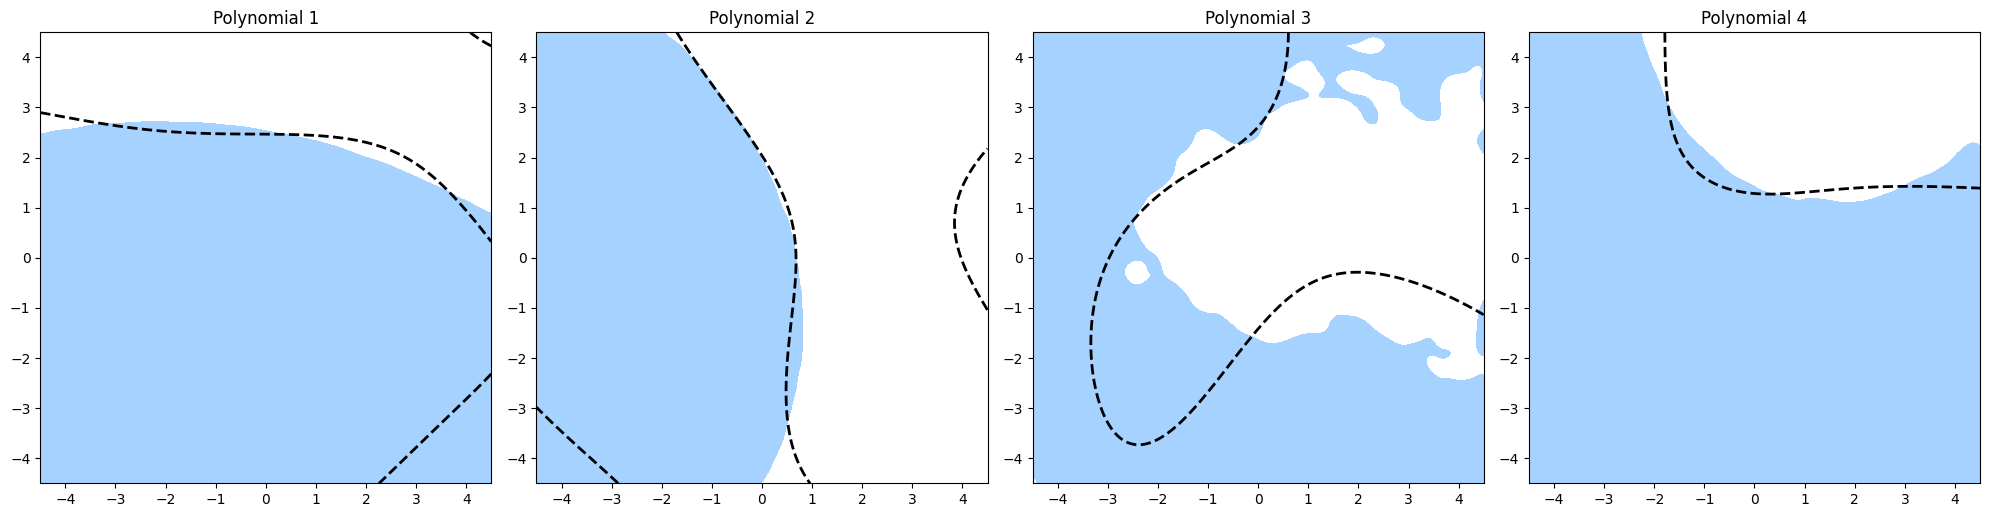

In [ ]:
test_final_pipeline(siren)

Extracting Functas (3 strict SGD steps)...
Extraction Loss: 0.234718 (Should be ~0.07 - 0.09)


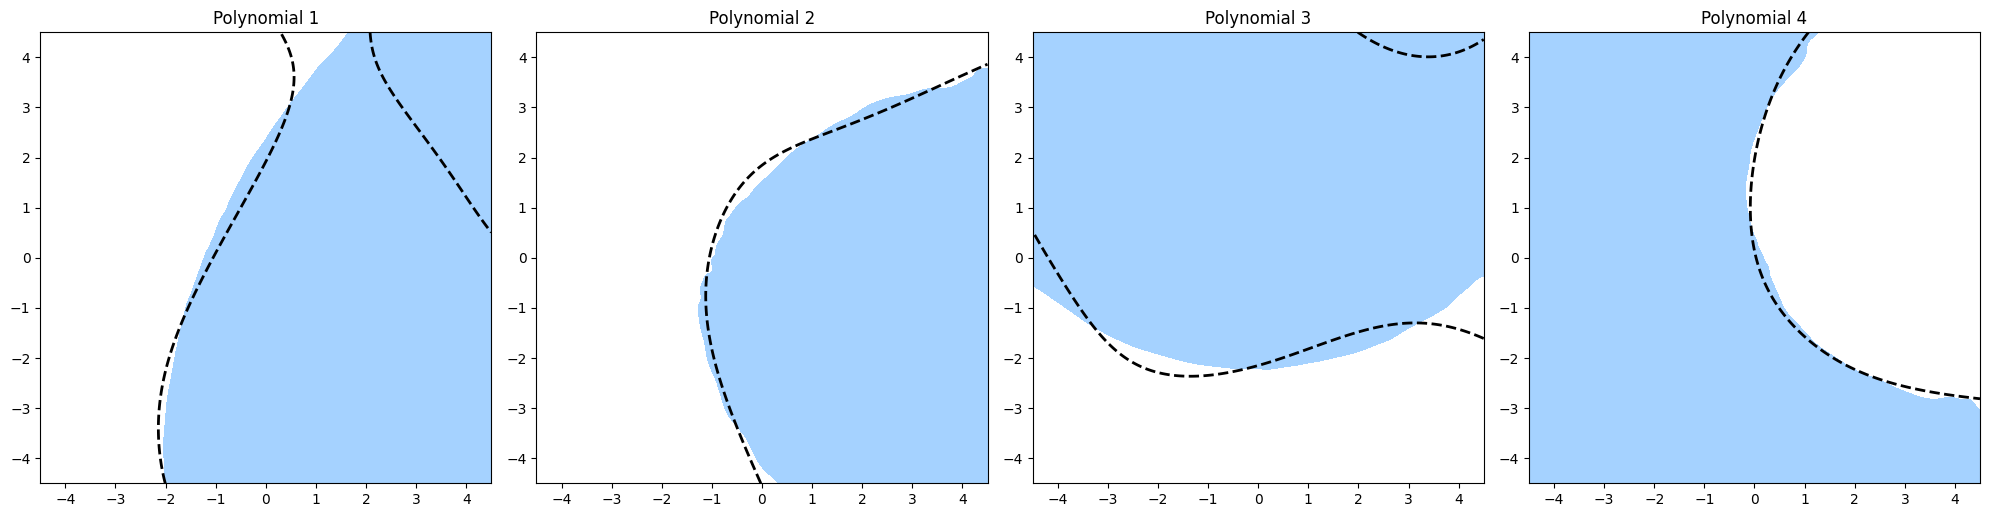

In [ ]:
test_final_pipeline(siren)